In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import warnings

# Optional modelling library. Available in Google Colab by default.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [ ]:
base_url = 'https://raw.githubusercontent.com/theomniscient-omnipotentrat/DBA-Final-Assignment/6d8b5a6f7e762e4d73bea18d7e24622f75441726/cleaned_dataset/'

def read_csv(name):
    url = os.path.join(base_url, name)
    df = pd.read_csv(url)
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
    return df

In [ ]:
customers = read_csv("customers_clean.csv")
orders = read_csv("orders_clean.csv")
deliveries = read_csv("deliveries_clean.csv")
drivers = read_csv("drivers_clean.csv")
vehicles = read_csv("vehicles_clean.csv")
hubs = read_csv("hubs_clean.csv")
complaints = read_csv("complaints_clean.csv")
incidents = read_csv("incidents_clean.csv")
app_events = read_csv("app_events_clean.csv")

customers_clean.csv: 650 rows, 10 columns
orders_clean.csv: 1,250 rows, 12 columns
deliveries_clean.csv: 950 rows, 24 columns
drivers_clean.csv: 170 rows, 10 columns
vehicles_clean.csv: 120 rows, 10 columns
hubs_clean.csv: 8 rows, 5 columns
complaints_clean.csv: 320 rows, 10 columns
incidents_clean.csv: 280 rows, 8 columns
app_events_clean.csv: 640 rows, 11 columns


In [ ]:
# -------------------------------------------------------------------
# 2. DATETIME CONVERSION
# -------------------------------------------------------------------
for col in ["dispatch_time", "delivery_completed_at"]:
    if col in deliveries.columns:
        deliveries[col] = pd.to_datetime(deliveries[col], errors="coerce")

for col in ["order_created_at"]:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")

for col in ["created_at"]:
    if col in complaints.columns:
        complaints[col] = pd.to_datetime(complaints[col], errors="coerce")

for col in ["reported_at"]:
    if col in incidents.columns:
        incidents[col] = pd.to_datetime(incidents[col], errors="coerce")

for col in ["event_timestamp"]:
    if col in app_events.columns:
        app_events[col] = pd.to_datetime(app_events[col], errors="coerce")


In [ ]:
# -------------------------------------------------------------------
# 3. BUILD AN INTEGRATED ANALYTICAL DATASET
# -------------------------------------------------------------------
# Aggregate semi-structured/event style data to order/delivery level for analytics.
complaint_features = (
    complaints
    .groupby("order_id", dropna=True)
    .agg(
        complaint_count=("complaint_id", "count"),
        avg_resolution_days=("resolution_days", "mean"),
        total_compensation=("compensation_amount", "sum"),
        high_severity_complaints=("severity", lambda s: (s == "High").sum()),
        open_complaints=("status", lambda s: (s == "Open").sum())
    )
    .reset_index()
)

incident_features = (
    incidents
    .groupby("delivery_id", dropna=True)
    .agg(
        incident_count=("incident_id", "count"),
        avg_resolved_hours=("resolved_hours", "mean"),
        critical_open_count=("is_critical_open", "sum"),
        high_severity_incidents=("severity", lambda s: (s == "High").sum())
    )
    .reset_index()
)

app_features = (
    app_events
    .dropna(subset=["order_id"])
    .groupby("order_id")
    .agg(
        app_event_count=("event_id", "count"),
        failed_app_events=("success_flag", lambda s: (s == 0).sum()),
        avg_api_latency_ms=("api_latency_ms", "mean"),
        max_api_latency_ms=("api_latency_ms", "max"),
        unlinked_app_events=("is_unlinked_session", "sum")
    )
    .reset_index()
)
app_features["app_failure_rate"] = app_features["failed_app_events"] / app_features["app_event_count"]

master = (
    deliveries
    .merge(orders[["order_id", "customer_id", "booking_channel", "special_handling_flag", "is_cross_zone"]],
           on="order_id", how="left")
    .merge(customers[["customer_id", "home_zone", "customer_type", "loyalty_score", "app_engagement_score", "engagement_segment", "account_status"]],
           on="customer_id", how="left")
    .merge(hubs.rename(columns={"zone": "hub_zone"})[["hub_id", "hub_name", "hub_zone", "hub_type", "capacity_score"]],
           on="hub_id", how="left")
    .merge(drivers[["driver_id", "base_zone", "employment_type", "years_experience", "training_score", "driver_rating", "performance_score", "performance_tier"]],
           on="driver_id", how="left")
    .merge(vehicles[["vehicle_id", "vehicle_type", "assigned_zone", "battery_health_pct", "odometer_km", "maintenance_status", "age_months", "maintenance_risk_flag"]],
           on="vehicle_id", how="left")
    .merge(complaint_features, on="order_id", how="left")
    .merge(incident_features, on="delivery_id", how="left")
    .merge(app_features, on="order_id", how="left")
)

# Replace missing aggregate counts with zero.
count_cols = [
    "complaint_count", "total_compensation", "high_severity_complaints", "open_complaints",
    "incident_count", "critical_open_count", "high_severity_incidents",
    "app_event_count", "failed_app_events", "unlinked_app_events"
]
for col in count_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0)



In [ ]:
# Define output directory
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------------------------
# 4. FEATURE ENGINEERING
# -------------------------------------------------------------------
master["failure_flag"] = (master["delivery_status"] == "Failed").astype(int)
master["complaint_flag"] = (master["complaint_count"] > 0).astype(int)
master["incident_flag"] = (master["incident_count"] > 0).astype(int)
master["cost_per_km"] = master["fuel_or_charge_cost"] / master["route_distance_km"].replace(0, np.nan)
master["route_override_flag"] = (master["manual_route_override_count"] > 0).astype(int)
master["high_latency_flag"] = (master["avg_api_latency_ms"].fillna(0) > 450).astype(int)
master["app_problem_flag"] = ((master["failed_app_events"] > 0) | (master["high_latency_flag"] == 1)).astype(int)
master["month"] = master["dispatch_time"].dt.to_period("M").astype(str)

# Composite operational risk score. This is not a predictive model; it is a transparent
# management indicator combining major risk signals from structured and event data.
master["operational_risk_score"] = (
    master["is_late"].fillna(0)
    + master["failure_flag"].fillna(0)
    + master["complaint_flag"].fillna(0)
    + master["incident_flag"].fillna(0)
    + master["maintenance_risk_flag"].fillna(0)
    + master["temporal_anomaly_flag"].fillna(0)
    + master["app_problem_flag"].fillna(0)
)
master["risk_segment"] = pd.cut(
    master["operational_risk_score"],
    bins=[-1, 0, 2, 10],
    labels=["Low", "Medium", "High"]
)

master.to_csv(os.path.join(OUTPUT_DIR, "northstar_master_analytics.csv"), index=False)
print("\nMaster analytical dataset saved:", os.path.join(OUTPUT_DIR, "northstar_master_analytics.csv"))


Master analytical dataset saved: output/northstar_master_analytics.csv


In [ ]:
# -------------------------------------------------------------------
# 5. DESCRIPTIVE ANALYTICS
# -------------------------------------------------------------------
overall_summary = pd.DataFrame({
    "metric": [
        "deliveries", "late_rate", "failure_rate", "complaint_rate", "incident_rate",
        "app_problem_rate", "high_risk_rate", "average_delay_hours", "average_rating", "average_cost_per_km"
    ],
    "value": [
        len(master),
        master["is_late"].mean(),
        master["failure_flag"].mean(),
        master["complaint_flag"].mean(),
        master["incident_flag"].mean(),
        master["app_problem_flag"].mean(),
        (master["risk_segment"] == "High").mean(),
        master["delay_hours"].mean(),
        master["customer_rating_post_delivery"].mean(),
        master["cost_per_km"].mean()
    ]
})
overall_summary.to_csv(os.path.join(OUTPUT_DIR, "overall_summary.csv"), index=False)
print("\nOverall summary")
print(overall_summary)

hub_risk = (
    master.groupby(["hub_id", "hub_name", "hub_zone"], dropna=False)
    .agg(
        deliveries=("delivery_id", "count"),
        late_rate=("is_late", "mean"),
        failure_rate=("failure_flag", "mean"),
        complaint_rate=("complaint_flag", "mean"),
        incident_rate=("incident_flag", "mean"),
        avg_risk_score=("operational_risk_score", "mean"),
        avg_rating=("customer_rating_post_delivery", "mean")
    )
    .reset_index()
    .sort_values("avg_risk_score", ascending=False)
)
hub_risk.to_csv(os.path.join(OUTPUT_DIR, "hub_risk_summary.csv"), index=False)

service_risk = (
    master.groupby("service_type", dropna=False)
    .agg(
        deliveries=("delivery_id", "count"),
        late_rate=("is_late", "mean"),
        failure_rate=("failure_flag", "mean"),
        complaint_rate=("complaint_flag", "mean"),
        avg_cost=("fuel_or_charge_cost", "mean"),
        avg_cost_per_km=("cost_per_km", "mean")
    )
    .reset_index()
    .sort_values("failure_rate", ascending=False)
)
service_risk.to_csv(os.path.join(OUTPUT_DIR, "service_risk_summary.csv"), index=False)

maintenance_risk = (
    master.groupby("maintenance_status", dropna=False)
    .agg(
        deliveries=("delivery_id", "count"),
        late_rate=("is_late", "mean"),
        failure_rate=("failure_flag", "mean"),
        complaint_rate=("complaint_flag", "mean"),
        incident_rate=("incident_flag", "mean"),
        avg_rating=("customer_rating_post_delivery", "mean")
    )
    .reset_index()
    .sort_values("failure_rate", ascending=False)
)
maintenance_risk.to_csv(os.path.join(OUTPUT_DIR, "maintenance_risk_summary.csv"), index=False)

risk_segment_summary = (
    master.groupby("risk_segment", observed=True)
    .agg(
        deliveries=("delivery_id", "count"),
        failure_rate=("failure_flag", "mean"),
        complaint_rate=("complaint_flag", "mean"),
        incident_rate=("incident_flag", "mean"),
        avg_delay_hours=("delay_hours", "mean"),
        avg_rating=("customer_rating_post_delivery", "mean")
    )
    .reset_index()
)
risk_segment_summary.to_csv(os.path.join(OUTPUT_DIR, "risk_segment_summary.csv"), index=False)

monthly_trend = (
    master.groupby("month")
    .agg(
        deliveries=("delivery_id", "count"),
        late_rate=("is_late", "mean"),
        failure_rate=("failure_flag", "mean"),
        complaint_rate=("complaint_flag", "mean"),
        avg_delay_hours=("delay_hours", "mean")
    )
    .reset_index()
)
monthly_trend.to_csv(os.path.join(OUTPUT_DIR, "monthly_trend.csv"), index=False)




Overall summary
                metric       value
0           deliveries  950.000000
1            late_rate    0.457895
2         failure_rate    0.138947
3       complaint_rate    0.220000
4        incident_rate    0.261053
5     app_problem_rate    0.146316
6       high_risk_rate    0.120000
7  average_delay_hours    2.930179
8       average_rating    3.864179
9  average_cost_per_km    1.261662


In [ ]:
# -------------------------------------------------------------------
# 7. SIMPLE PREDICTIVE MODEL FOR FAILURE RISK
# -------------------------------------------------------------------
# The model is used for explanatory analytics, not automated decision-making.
model_features = [
    "service_type", "priority_level", "pickup_zone", "dropoff_zone", "hub_zone",
    "employment_type", "performance_tier", "vehicle_type", "maintenance_status",
    "route_distance_km", "manual_route_override_count", "proof_of_completion_missing",
    "fuel_or_charge_cost", "training_score", "driver_rating", "battery_health_pct",
    "capacity_score", "is_cross_zone", "special_handling_flag", "app_problem_flag",
    "incident_flag", "complaint_flag"
]

model_df = master[model_features + ["failure_flag"]].copy()
X = model_df[model_features]
y = model_df["failure_flag"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [col for col in X.columns if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\nFailure risk model evaluation")
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(classification_report(y_test, y_pred))

# Extract coefficient direction as a transparent explanatory output.
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
coefs = clf.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)
print("\nModel Coefficients for Failure Risk:")
print(coef_table)



Failure risk model evaluation
ROC-AUC: 0.717
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       245
           1       0.25      0.62      0.36        40

    accuracy                           0.68       285
   macro avg       0.58      0.66      0.57       285
weighted avg       0.83      0.68      0.73       285


Model Coefficients for Failure Risk:
                              feature  coefficient  abs_coefficient
54   cat__maintenance_status_InRepair     1.257619         1.257619
18       cat__priority_level_Critical    -1.021413         1.021413
38                 cat__hub_zone_East    -0.842867         0.842867
51               cat__vehicle_type_EV    -0.827992         0.827992
37              cat__hub_zone_Central     0.782427         0.782427
55  cat__maintenance_status_Scheduled    -0.742826         0.742826
46        cat__performance_tier_Elite    -0.662509         0.662509
21         cat__priority_level_Medium     0.5

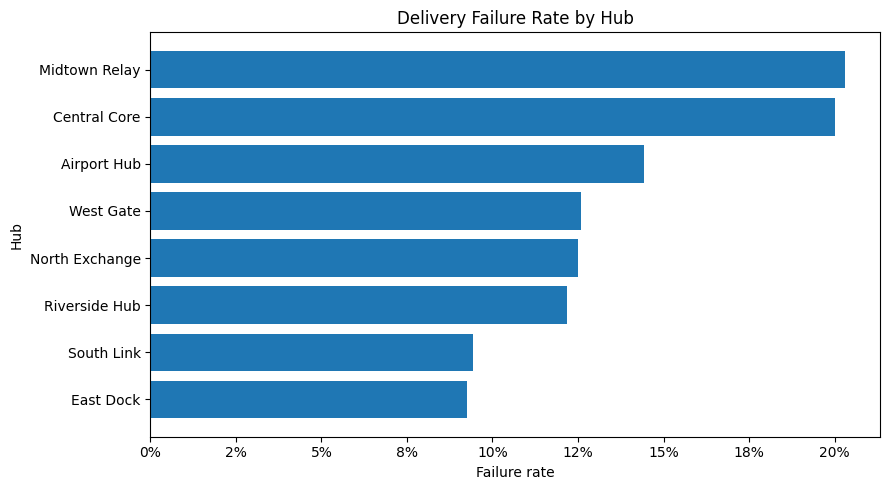

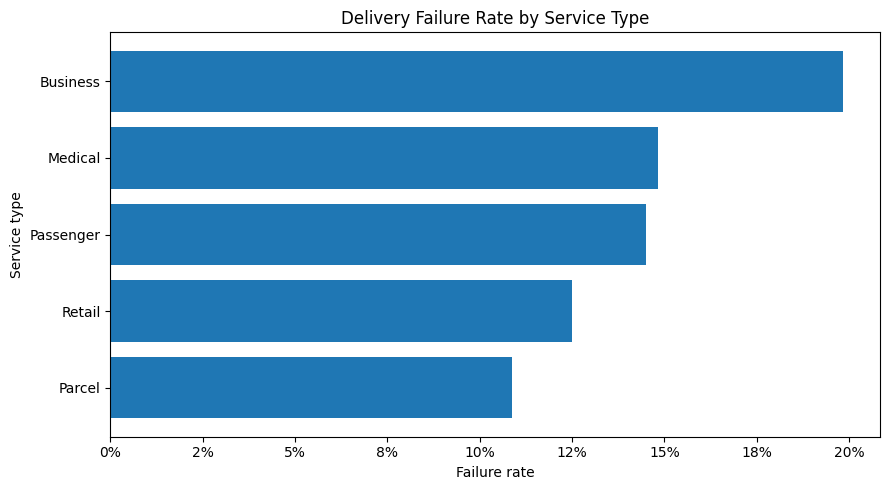

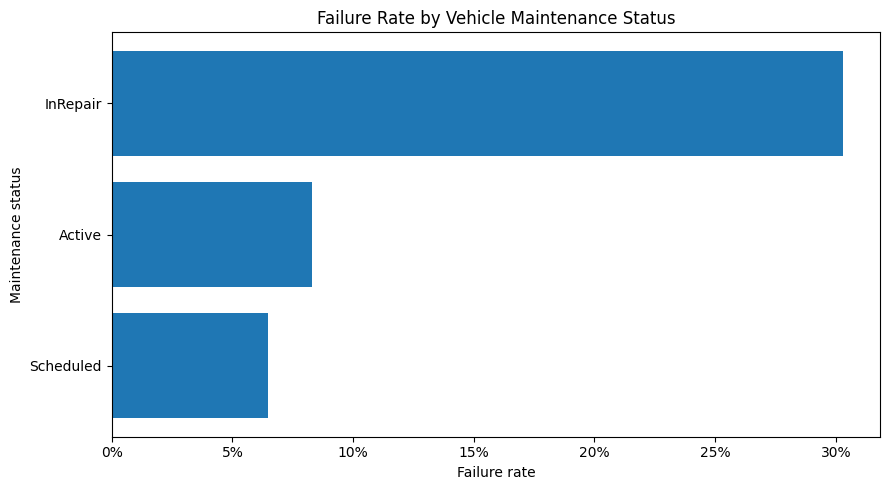

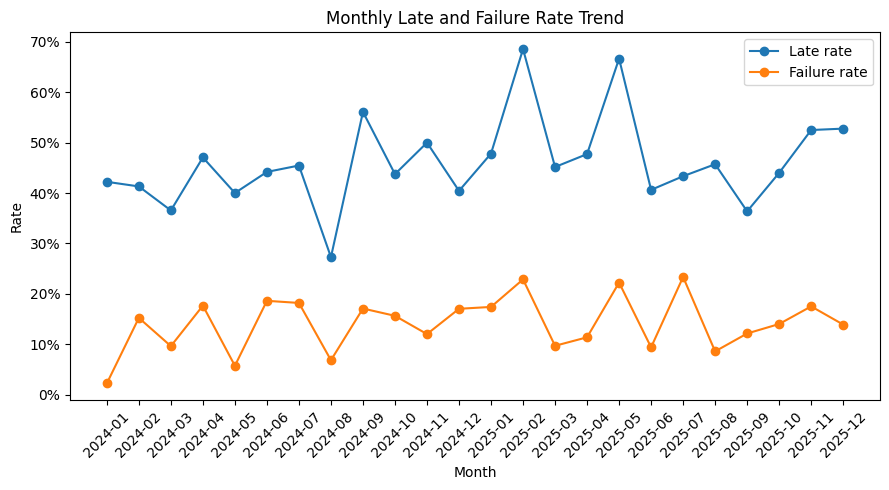

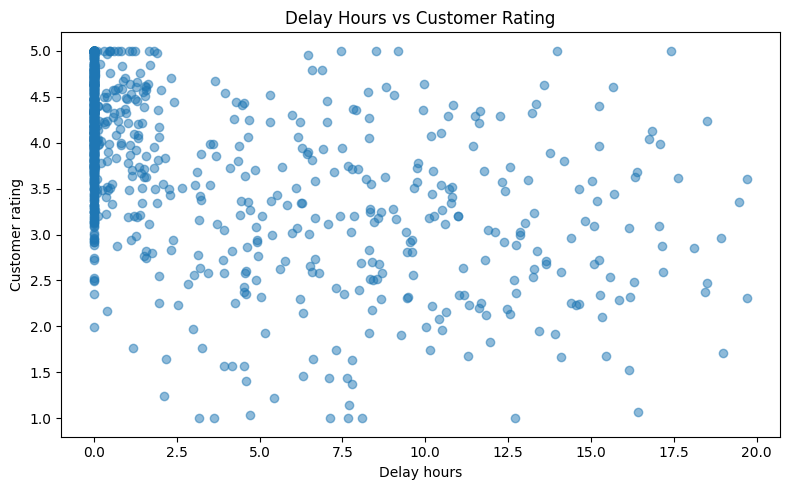

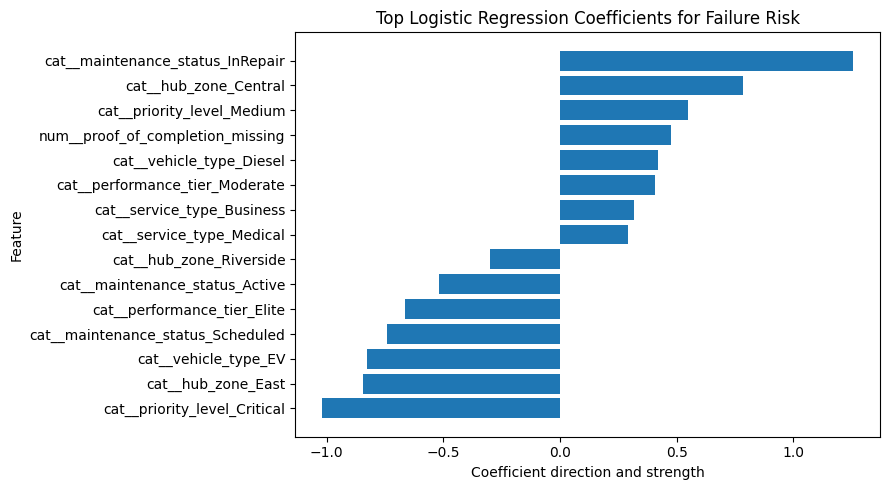

In [ ]:
# -------------------------------------------------------------------
# 8. CHARTS FOR REPORT
# -------------------------------------------------------------------
def save_bar(df, x_col, y_col, title, xlabel, ylabel, filename, percent=False):
    plot_df = df.copy().sort_values(y_col, ascending=True)
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df[x_col].astype(str), plot_df[y_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if percent:
        plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.tight_layout()
    plt.show()

save_bar(hub_risk, "hub_name", "failure_rate", "Delivery Failure Rate by Hub", "Failure rate", "Hub", "failure_rate_by_hub.png", percent=True)
save_bar(service_risk, "service_type", "failure_rate", "Delivery Failure Rate by Service Type", "Failure rate", "Service type", "failure_rate_by_service.png", percent=True)
save_bar(maintenance_risk, "maintenance_status", "failure_rate", "Failure Rate by Vehicle Maintenance Status", "Failure rate", "Maintenance status", "failure_rate_by_maintenance.png", percent=True)

plt.figure(figsize=(9, 5))
plt.plot(monthly_trend["month"], monthly_trend["late_rate"], marker="o", label="Late rate")
plt.plot(monthly_trend["month"], monthly_trend["failure_rate"], marker="o", label="Failure rate")
plt.title("Monthly Late and Failure Rate Trend")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(master["delay_hours"], master["customer_rating_post_delivery"], alpha=0.5)
plt.title("Delay Hours vs Customer Rating")
plt.xlabel("Delay hours")
plt.ylabel("Customer rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
top_coef = coef_table.head(15).sort_values("coefficient")
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Top Logistic Regression Coefficients for Failure Risk")
plt.xlabel("Coefficient direction and strength")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
